In [1]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from finsler_embedding.disbm import *
from finsler_embedding.operators import *
from finsler_embedding.utils import get_bounds, get_grid_pts
import pandas as pd

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [ ]:
K = 15
m = 2
eps_scale = .10

r = 0.1


eps_scale = 1.0
frames  = []
for N in [500, 1000, 2000, 4000]:
# for N in [1000]:
    for p in torch.linspace(0.0,1-r,20):
        q = 1 - p - r
        print(f"Running experiment with N={N}, p={p:.2f}, q={q:.2f}, r={r}")
        edges, dst_edges, community_labels, A = graph_info(p,q,r,K,N)
        epsilon = 1
        W = apply_gaussian_kernel(edges, dst_edges, epsilon, N)
        # Leading eigenvectors of L^s (symmetric part of the theta-normalized kernel, theta = 1)
        W_theta_s, _ = get_W_thetas(W, get_Q_inv_theta(W, theta=1))
        X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.numpy())
        X_low = torch.from_numpy(X_low).float()
        results = randers_approximation(W, epsilon, m=m,X_low=X_low)
        c_norm_sq = results["c_norm_sq"]
        for i in range(N):
            frames.append({
                "N": N,
                "c_norm_sq": c_norm_sq[i].item(),
                "p": p.item(),
                "q": q.item(),
                "r": r,
            })

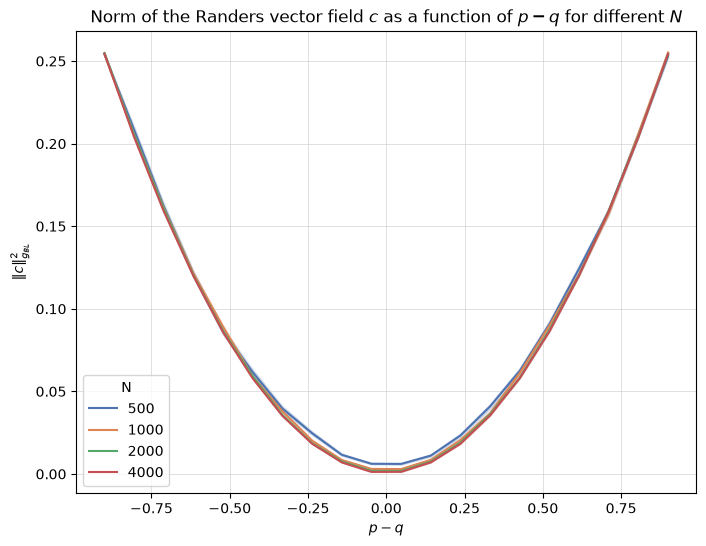

In [3]:
df = pd.DataFrame(frames)
df["p-q"] = df["p"] - df["q"]

# sns.barplot(x="N", y="c_norm_sq", data=df)
# plt.gca().set_ylabel(r"$\|c\|^2_{g_{BL}}$")

fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(
    data=df, 
    x="p-q",
    y="c_norm_sq", 
    hue="N",
    errorbar=("ci", 90), 
    # errorbar=("sd"), 
    palette="deep",
    ax=ax)
ax.set_ylabel(r"$\|c\|^2_{g_{BL}}$")
ax.set_xlabel(r"$p - q$")
ax.grid(visible=True, which='major', color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_title(r"Norm of the Randers vector field $c$ as a function of $p-q$ for different $N$")
plt.show()

In [12]:
df.loc[(df.p > 0.45) & (df.p < 0.55)]

,N,c_norm_sq,p,q,r,p-q
5000,500,0.001776,0.473684,0.426316,0.1,0.047368
5001,500,0.000699,0.473684,0.426316,0.1,0.047368
5002,500,0.005668,0.473684,0.426316,0.1,0.047368
5003,500,0.004342,0.473684,0.426316,0.1,0.047368
5004,500,0.018504,0.473684,0.426316,0.1,0.047368
...,...,...,...,...,...,...
117995,4000,0.007515,0.521053,0.378947,0.1,0.142105
117996,4000,0.004310,0.521053,0.378947,0.1,0.142105
117997,4000,0.004930,0.521053,0.378947,0.1,0.142105
117998,4000,0.010105,0.521053,0.378947,0.1,0.142105


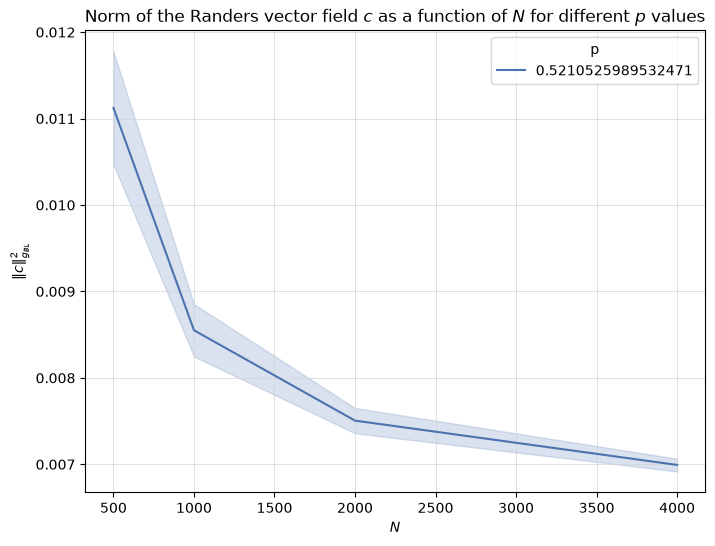

In [20]:
fig, ax = plt.subplots(figsize=(8,6))
sns.lineplot(
    data=df.loc[(df.p > 0.49) & (df.p < 0.53)], 
    # data=df, 
    x="N",
    y="c_norm_sq", 
    hue="p",
    errorbar=("ci", 90), 
    # errorbar=("sd"), 
    palette="deep",
    ax=ax)
ax.set_ylabel(r"$\|c\|^2_{g_{BL}}$")
ax.set_xlabel(r"$N$")
ax.grid(visible=True, which='major', color='lightgrey', linestyle='-', linewidth=0.5)
ax.set_title(r"Norm of the Randers vector field $c$ as a function of $N$ for different $p$ values")
plt.show()